## Pytorch Workflow

In [ ]:
# pytorch workflow
what_were_covering = {1: "data (prepare and load)",
                      2: "build a model",
                      3: "fitting the model to data (training)",
                      4: "making predictions and evaluating a model (inference)"}



what_were_covering



{1: 'data (prepare and load)',
 2: 'build a model',
 3: 'fitting the model to data (training)',
 4: 'making predictions and evaluating a model (inference)'}

In [ ]:
import torch
from torch import nn # nn contains all of pytorch's building blocks for
import matplotlib.pyplot as plt

# check pytorch version
torch.__version__

'2.10.0+cpu'

## Data preparing and Loading

In [ ]:
# Create *known* parameters
weight = 0.7
bias = 0.3
# create
start = 0
end = 1
step = 0.02
x = torch.arange(start, end, step).unsqueeze(dim = 1)
y = weight*x + bias
x[: 10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [ ]:
len(x), len(y)

(50, 50)

## Spliting data in to training and testing sets (one of the most important concept in machine learning  in general)

In [ ]:
 # create train test split
 train_split =int(0.8*len(x))
 x_train, y_train = x[:train_split], y[:train_split]
 x_test, y_test = x[train_split], y[train_split]

 len(x_train), len(y_train), len(x_test), len(y_test)

(40, 40, 1, 1)

In [ ]:
x_train, y_train

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800],
         [0.2000],
         [0.2200],
         [0.2400],
         [0.2600],
         [0.2800],
         [0.3000],
         [0.3200],
         [0.3400],
         [0.3600],
         [0.3800],
         [0.4000],
         [0.4200],
         [0.4400],
         [0.4600],
         [0.4800],
         [0.5000],
         [0.5200],
         [0.5400],
         [0.5600],
         [0.5800],
         [0.6000],
         [0.6200],
         [0.6400],
         [0.6600],
         [0.6800],
         [0.7000],
         [0.7200],
         [0.7400],
         [0.7600],
         [0.7800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260],
         [0.4400],
         [0.4540],
         [

### how might we better visualize our data?

In [ ]:
def plot_predictions(train_data = x_train,
                     train_labels = y_train,
                     test_data = x_test,
                     test_labels = y_test,
                     predictions = None):

  """
  plot training data, test dta and compares predictions.
  """

  plt.figure(figsize=(10,7))
  # plot training data in blue
  plt.scatter(train_data,train_labels, c="b", s=4, label="tranining data")

  # plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="training data")

  # Are there predictions?
  if predictions is not None:
    # plot the predictions if they exist
    plt.scatter(test_data, predictions, c="r", s=4, label= "predictions")
    # show legend
    plt.legend(prop={"size": 14})



(None,)

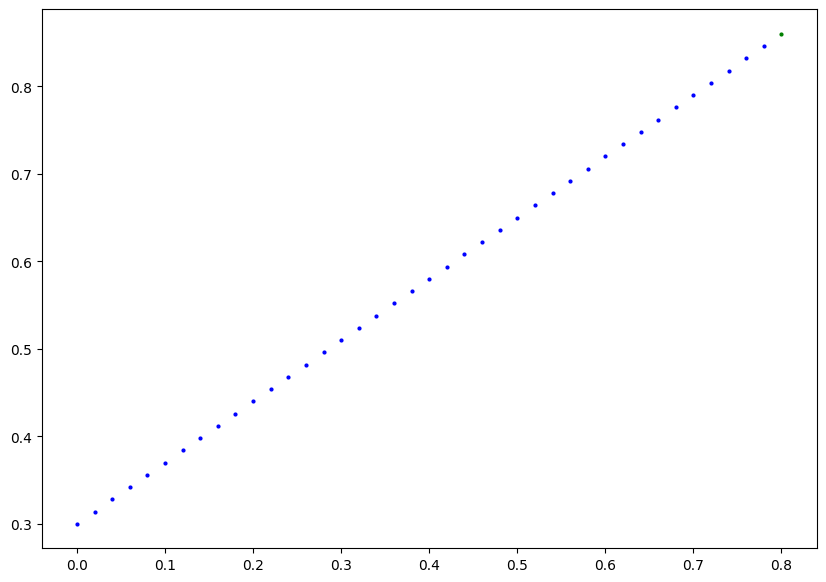

In [ ]:
 plot_predictions(),

## Building model

Our first Pytorch model !
this is very exciting...let's do it

In [ ]:
from torch import nn
# create linear regression model class
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()

    # initialize model parameters
    self.weights = nn.Parameter(torch.randn(1,
                                            requires_grad= True,
                                            dtype = torch.float))
    self.bias = nn.Parameter(torch.randn(1,
                                         requires_grad= True,
                                         dtype = torch.float))


# Forward method to define the computation in the model
  def forward(self, x: torch.Tensor) -> torch.Tensor:
   return self.weights*x+ self.bias # this is the linear regression formula




## Pytorch model Building essentials

### checking thr content of Pytorch model

now we have created a model , let's see what's inside

In [ ]:
# create a random seed
torch.manual_seed(42)
# create an instance of the model
model_0 = LinearRegressionModel()
# check out the parameters
list(model_0.parameters())



[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
# list name parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [ ]:
weight, bias

(0.7, 0.3)

In [ ]:
# make prediction with model
with torch.inference_mode():
  y_preds = model_0(x_test)

with torch.no_grad():
   y_preds = model_0(x_test)


y_preds




tensor([0.3982])

### Making predictions using torch.inference_model()



In [ ]:
y_test

tensor([0.8600])

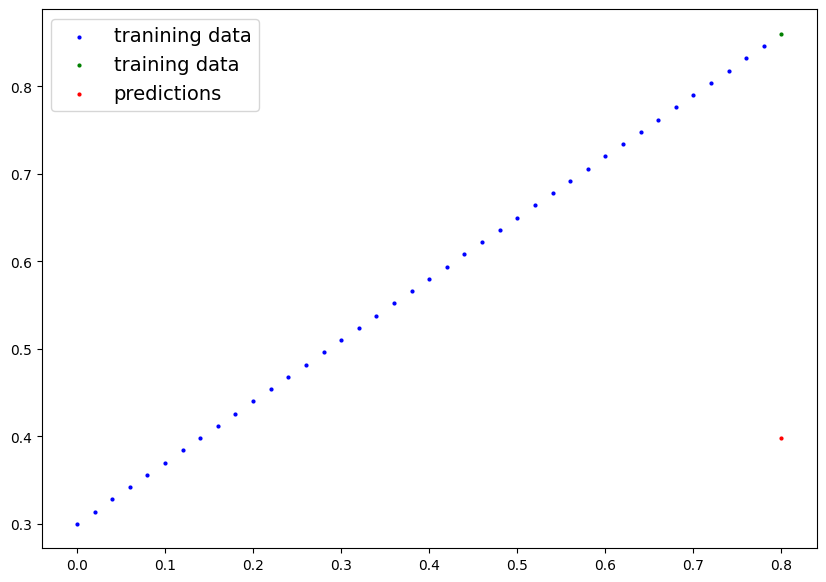

In [ ]:
plot_predictions(predictions=y_preds)

### 3 Train model

In [ ]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [ ]:
# setup a loss function
loss_fn = nn.L1Loss()

# setup an optimizers
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.01)

### Building a Trainig Loop

In [ ]:
# an epochs is one loop through the data...
epochs = 200
epoch_count =[]
loss_values = []
test_loss_values = []

# 0, Loop through the data
for epoch in range(epochs):
  # set the model to training mode
  model_0.train() # training mode in pytorch mode


  # 1. Forward pass
  y_pred = model_0(x_train)

  # 2. calculate the loss
  loss = loss_fn(y_pred, y_train)
  # 3. optimizer zero grad
  optimizer.zero_grad()

  # 4. perform backpropagation
  loss.backward()

  # 5.step the optimizer
  optimizer.step()

  # Testing


  model_0.eval() # turns off the gradient tracking
  with torch.inference_mode():# turns off gradient tracking & a couple more things behind
  #with torch.no_grad():# you may also see torch.no_grad()
     # 1. do the forward pass
     test_pred = model_0(x_test)

     # 2. calculate the loss
     test_loss = loss_fn(test_pred, y_test)

  # print out what's happenung
  if epoch % 10 == 0:
    epoch_count.append(epoch)
    loss_values.append(loss.item())
    test_loss_values.append(test_loss)
    print(f"Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}")


  print(model_0.state_dict())


Epoch: 0 | Loss: 0.31288138031959534 | Test loss: 0.4487183094024658
OrderedDict({'weights': tensor([0.3406]), 'bias': tensor([0.1388])})
OrderedDict({'weights': tensor([0.3445]), 'bias': tensor([0.1488])})
OrderedDict({'weights': tensor([0.3484]), 'bias': tensor([0.1588])})
OrderedDict({'weights': tensor([0.3523]), 'bias': tensor([0.1688])})
OrderedDict({'weights': tensor([0.3562]), 'bias': tensor([0.1788])})
OrderedDict({'weights': tensor([0.3601]), 'bias': tensor([0.1888])})
OrderedDict({'weights': tensor([0.3640]), 'bias': tensor([0.1988])})
OrderedDict({'weights': tensor([0.3679]), 'bias': tensor([0.2088])})
OrderedDict({'weights': tensor([0.3718]), 'bias': tensor([0.2188])})
OrderedDict({'weights': tensor([0.3757]), 'bias': tensor([0.2288])})
Epoch: 10 | Loss: 0.1976713240146637 | Test loss: 0.31751835346221924
OrderedDict({'weights': tensor([0.3796]), 'bias': tensor([0.2388])})
OrderedDict({'weights': tensor([0.3835]), 'bias': tensor([0.2488])})
OrderedDict({'weights': tensor([0

In [ ]:
import numpy as np

# Convert loss values to numpy array and create tuple
loss_array = np.array(loss_values)  # loss_values is already a list of floats
result = (loss_array, test_loss_values)

print(result)

(array([0.31288138, 0.19767132, 0.08908726, 0.05314853, 0.04543797,
       0.04167863, 0.03818933, 0.0347609 , 0.03132383, 0.0278874 ,
       0.02445896, 0.02102021, 0.01758547, 0.01415539, 0.01071659,
       0.00728353, 0.00385178, 0.00893248, 0.00893248, 0.00893248]), [tensor(0.4487), tensor(0.3175), tensor(0.1920), tensor(0.1222), tensor(0.0933), tensor(0.0806), tensor(0.0719), tensor(0.0652), tensor(0.0585), tensor(0.0524), tensor(0.0457), tensor(0.0389), tensor(0.0329), tensor(0.0261), tensor(0.0194), tensor(0.0134), tensor(0.0066), tensor(0.0046), tensor(0.0046), tensor(0.0046)])


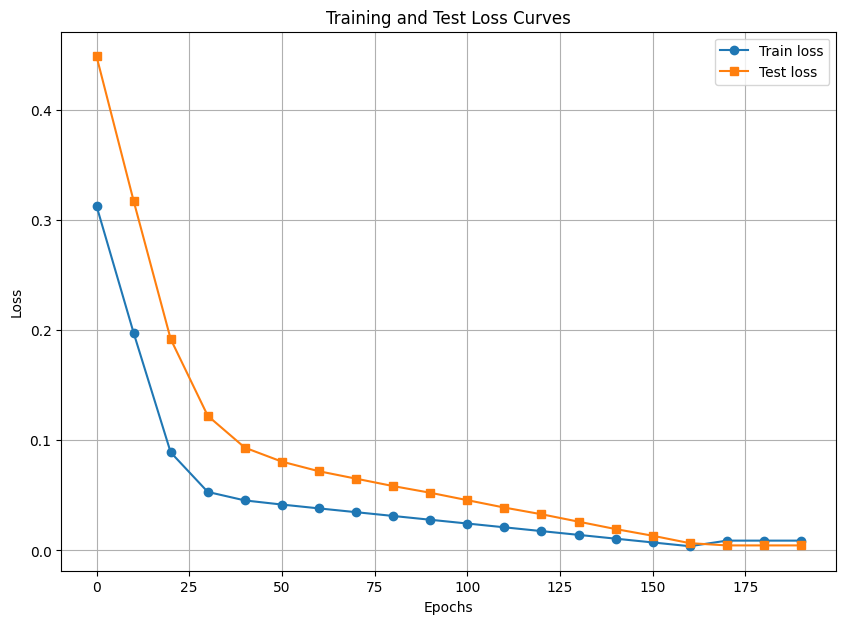

In [ ]:
# Plot the loss curves
plt.figure(figsize=(10, 7))
plt.plot(epoch_count, loss_values, label="Train loss", marker='o')
plt.plot(epoch_count, test_loss_values, label="Test loss", marker='s')
plt.title("Training and Test Loss Curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [ ]:
with torch.inference_mode():
  y_preds_new = model_0(x_test)

In [ ]:
weight, bias

(0.7, 0.3)

(None,)

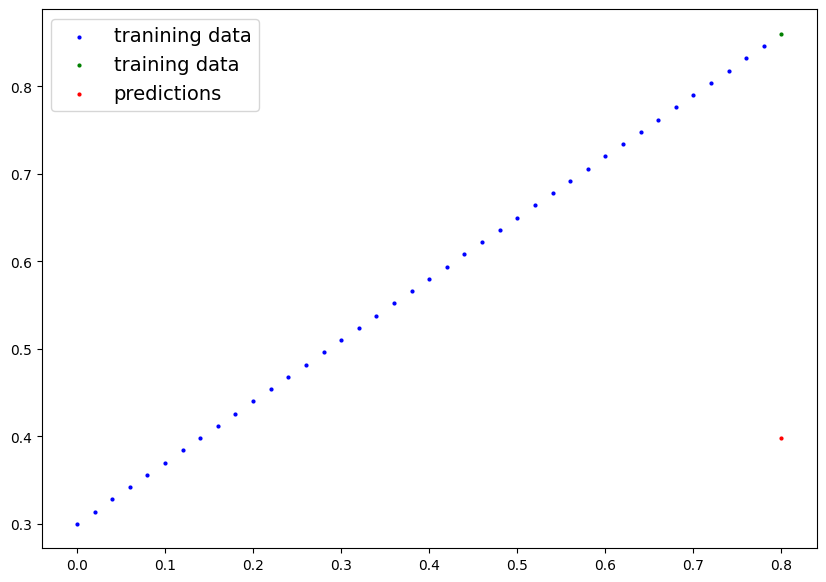

In [ ]:
plot_predictions(predictions=y_preds),

(None,)

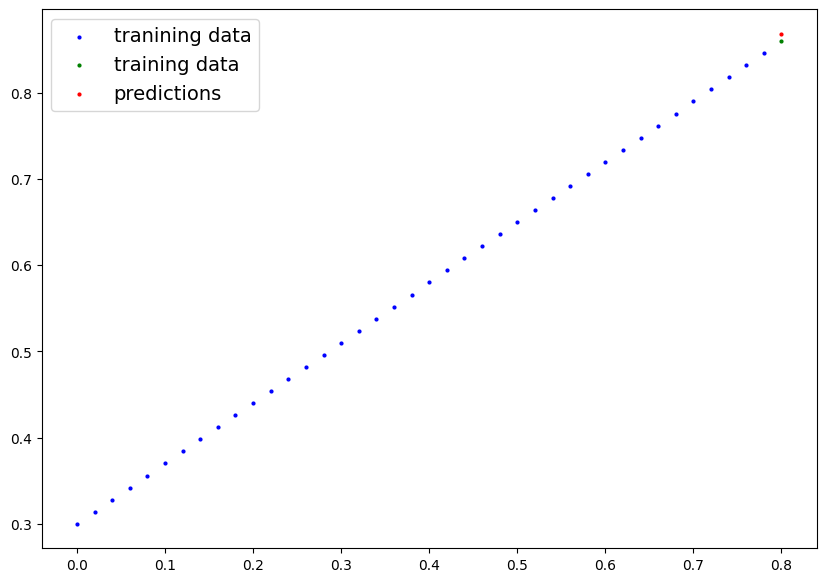

In [ ]:
plot_predictions(predictions=y_preds_new),

In [ ]:
model_0

LinearRegressionModel()

### Saving a model in Pytorch

* 1 Torch.save()
* 2 Torch.load()
* 3 Torch.nn.Module.Load_state_dict()

In [ ]:
# saving our pytorch model
from pathlib import Path

# 1. create models directory

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents = True, exist_ok=True)

# 2. create the model save path
MODEL_NAME = "01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. save the model state dict
print(f"saving model to: {MODEL_SAVE_PATH}")

torch.save(obj=model_0.state_dict(),
           f=MODEL_SAVE_PATH)

saving model to: models/01_pytorch_workflow_model_0.pth


In [ ]:
!ls -l models

total 4
-rw-r--r-- 1 root root 2117 Apr 20 19:41 01_pytorch_workflow_model_0.pth


### Loading a Pytorch Model

In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [ ]:
# Toload in a saved state_dict we have to instantiate a new instance of our model class
loaded_model_0 = LinearRegressionModel()

# load the saved state_dict of model_0
loaded_model_0.load_state_dict(torch.load(f= MODEL_SAVE_PATH))


<All keys matched successfully>

In [ ]:
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [ ]:
# Make some prediction with our loaded model
loaded_model_0.eval()
with torch.inference_mode():
  loaded_model_preds = loaded_model_0(x_test)

loaded_model_preds

tensor([0.8685])

In [ ]:
# compare loaded model preds with original model preds

y_pred == loaded_model_preds

tensor([[False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False]])

In [ ]:
y_preds

tensor([0.3982])

In [ ]:
# make some models preds

model_0.eval()
with torch.inference_mode():
  y_preds = model_0(x_test)

y_preds

tensor([0.8685])

In [ ]:
y_preds == loaded_model_preds

tensor([True])

### Putting it all Together

In [ ]:
# Import pytorch and matplotlib
import torch
from torch import nn
import matplotlib.pyplot as plt


# check pytorch version

torch.__version__


'2.10.0+cpu'

##### creat device-agnostic code.

In [ ]:
# setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Using device: {device}")


Using device: cpu


#### 6.1 Data

In [ ]:
# create some data using linear regression formula
weight = 0.7
bias = 0.3

# create range values
start =0
end = 1
step = 0.02
# create x and y
x = torch.arange(start, end, step).unsqueeze(dim=1)# with out unsqueeze, errors will pop
y = weight*x+ bias
x[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [ ]:
# split data
train_split = int(0.8*len(x))
x_train, y_train = x[:train_split], y[:train_split]
x_test, y_test = x[train_split:], y[train_split:]
len(x_train), len(y_train), len(x_test), len(y_test)


(40, 40, 10, 10)

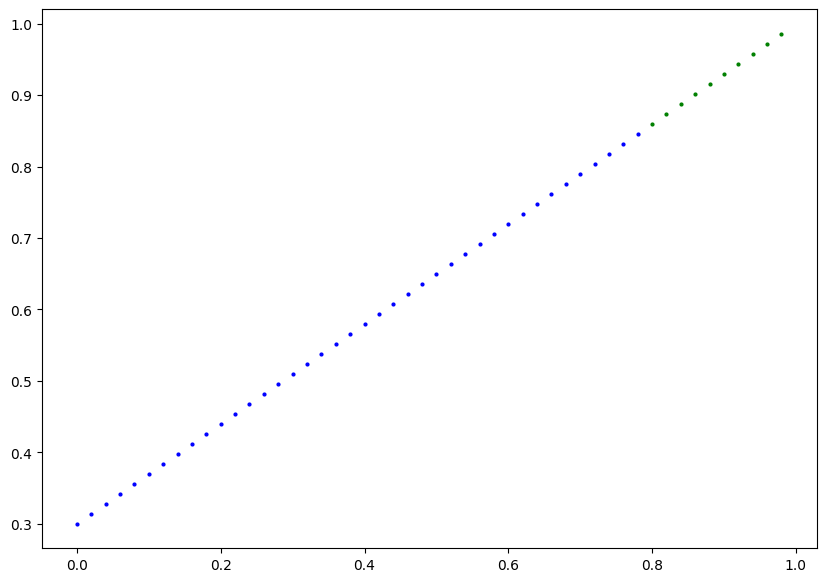

In [ ]:
# plot the data
plot_predictions(x_train, y_train, x_test, y_test)

### 6.2 Building a pytorch Linear Model

In [ ]:
# create a linear model by subclassing nn.module
class LinearRegressionModelv2(nn.Module):
  def __init__(self):
    super().__init__()
    # use nn.linear() for creating the model parameters
    self.linear_layer = nn.Linear(in_features =1,
                                  out_features=1)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.linear_layer(x)

# set the manual seed
torch.manual_seed(42)
model_1 = LinearRegressionModelv2()
model_1, model_1.state_dict()




(LinearRegressionModelv2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

### 6.3 Training


for training function we neeed:
*loss function
*optimizer
*Training Loop
*
Testing Loop

In [ ]:
#setup loss function
loss_fn = nn.L1Loss()

#setup our optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr = 0.01)

In [ ]:
# Let's write a training loop
torch.manual_seed(42)

epochs = 200

for epoch in range(epochs):
    model_1.train()
    # 1. forward pass
    y_pred = model_1(x_train)

    # 2. calculate the loss
    loss = loss_fn(y_pred, y_train)

    # 3. optimizer zero grad
    optimizer.zero_grad()

    # 4. perform backpropagation
    loss.backward()

    # 5. optimizer step
    optimizer.step()

    ### Testing
    model_1.eval()
    with torch.inference_mode():
        test_pred = model_1(x_test)
        test_loss = loss_fn(test_pred, y_test)

    # print out what's happening
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}")

Epoch: 0 | Loss: 0.5551779866218567 | Test loss: 0.5739762187004089
Epoch: 10 | Loss: 0.4399680495262146 | Test loss: 0.4392663538455963
Epoch: 20 | Loss: 0.3247582018375397 | Test loss: 0.30455657839775085
Epoch: 30 | Loss: 0.20954827964305878 | Test loss: 0.16984674334526062
Epoch: 40 | Loss: 0.09433844685554504 | Test loss: 0.03513689711689949
Epoch: 50 | Loss: 0.023886386305093765 | Test loss: 0.04784906655550003
Epoch: 60 | Loss: 0.0199567973613739 | Test loss: 0.04580312222242355
Epoch: 70 | Loss: 0.016517987474799156 | Test loss: 0.0375305712223053
Epoch: 80 | Loss: 0.013089170679450035 | Test loss: 0.029944902285933495
Epoch: 90 | Loss: 0.009653178043663502 | Test loss: 0.02167237363755703
Epoch: 100 | Loss: 0.006215679459273815 | Test loss: 0.014086711220443249
Epoch: 110 | Loss: 0.002787243574857712 | Test loss: 0.005814164876937866
Epoch: 120 | Loss: 0.0012645035749301314 | Test loss: 0.013801807537674904
Epoch: 130 | Loss: 0.0012645035749301314 | Test loss: 0.01380180753767

In [ ]:
weight, bias

(0.7, 0.3)

In [ ]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]])),
             ('linear_layer.bias', tensor([0.3025]))])

### Making and evaluating predictions

In [ ]:
# turn model into evaluation mode
model_1.eval()

# make predictions on the test data
with torch.inference_mode():
  y_preds = model_1(x_test)

y_preds

tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157],
        [0.9296],
        [0.9436],
        [0.9575],
        [0.9714],
        [0.9854]])

ValueError: x and y must be the same size

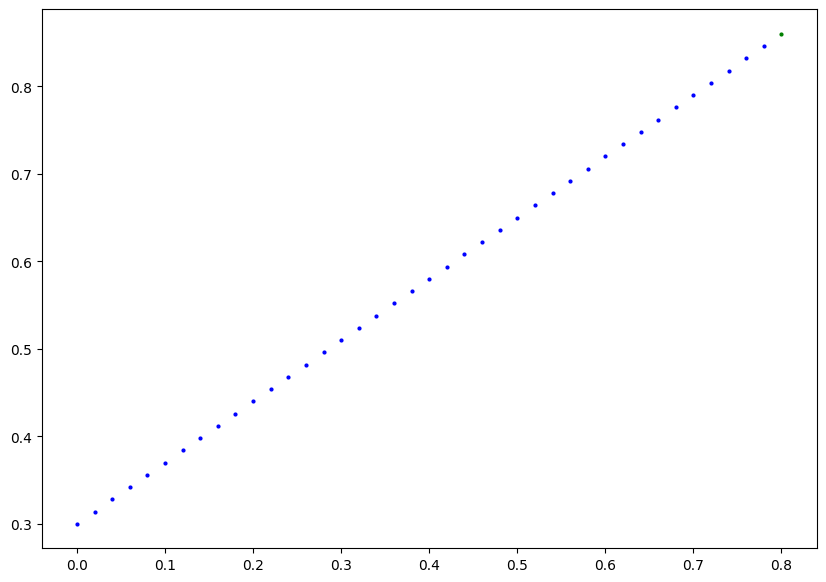

In [ ]:
# check out our model prediction visualy
plot_predictions(predictions=y_preds.cpu())

### 6.5 Saving and Loading Model

In [ ]:
from pathlib import Path

# 1. create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. create the model save path
MODEL_NAME = "01_pytorch_workflow_model_1.pth"  # Note: changed .path to .pth
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME  # Fixed: Use MODEL_NAME, not MODEL_SAVE_PATH

# save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_1.state_dict(),
           f=MODEL_SAVE_PATH)

Saving model to: models/01_pytorch_workflow_model_1.pth


In [ ]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]])),
             ('linear_layer.bias', tensor([0.3025]))])

In [ ]:
# load a pytorch model

# create a new instance of linear regression model v2
loaded_model_1 = LinearRegressionModelv2()

# Load the saved model_1 state_dict()

loaded_model_1.load_state_dict(torch.load(MODEL_SAVE_PATH))

# Put the loaded model to device

loaded_model_1.to(device)


LinearRegressionModelv2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [ ]:
loaded_model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]])),
             ('linear_layer.bias', tensor([0.3025]))])

In [ ]:
# evaluate the model
loaded_model_1.eval()
with torch.inference_mode():
  loaded_model_1_preds = loaded_model_1(x_test)

y_preds == loaded_model_1_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])